In [ ]:
# Read in processed summary data


df = spark.read.parquet("spark_output/practice_bnf_chapter")

df.show(5)
df.printSchema()

+-------------+--------------------+--------+--------------------+---------------------+-----------+-----------+-------------------+--------------------+
|PRACTICE_CODE|       PRACTICE_NAME|ICB_CODE|            ICB_NAME|BNF_CHAPTER_PLUS_CODE| total_cost|total_items|practice_total_cost|          cost_share|
+-------------+--------------------+--------+--------------------+---------------------+-----------+-----------+-------------------+--------------------+
|       DXV998|UNIDENTIFIED DOCTORS|     QOP|NHS GREATER MANCH...| 01: Gastro-Intest...|   98.91876|         11| 117870.68132999998|8.392142887768614E-4|
|       G85028|STOCKWELL GROUP P...|     QKK|NHS SOUTH EAST LO...| 07: Obstetrics, G...|48650.76147|       7297| 1366560.6378199998| 0.03560088013921572|
|       D82046| CHURCH HILL SURGERY|     QMM|NHS NORFOLK AND W...|       05: Infections|14656.23974|       3496|  989092.1417000002|0.014817870976923967|
|       F83671|THE BEAUMONT PRAC...|     QMJ|NHS NORTH CENTRAL...|        20

In [ ]:
# Compute total cost and items values


from pyspark.sql import functions as F

chapter_totals = (
    df.groupBy("BNF_CHAPTER_PLUS_CODE")
    .agg(
        F.sum("total_cost").alias("total_cost"),
        F.sum("total_items").alias("total_items")
    )
)

In [ ]:

# Generate summary table for cost and cost % by bnf chapter code


from pyspark.sql import functions as F


chapter_cost_only = chapter_totals.select("BNF_CHAPTER_PLUS_CODE", "total_cost")


grand_total_cost = chapter_cost_only.agg(
    F.sum("total_cost").alias("grand_total")
).collect()[0]["grand_total"]


chapter_cost_with_pct = chapter_cost_only.withColumn(
    "cost_pct",
    (F.col("total_cost") / F.lit(grand_total_cost)) * 100
)


chapter_cost_sorted = chapter_cost_with_pct.orderBy(
    F.desc("total_cost")
)


chapter_cost_sorted.show(50, truncate=False)

+-------------------------------------------------------+--------------------+--------------------+
|BNF_CHAPTER_PLUS_CODE                                  |total_cost          |cost_pct            |
+-------------------------------------------------------+--------------------+--------------------+
|06: Endocrine System                                   |2.299941858806675E9 |21.47681460812499   |
|04: Central Nervous System                             |1.515167523258959E9 |14.14860635397473   |
|03: Respiratory System                                 |1.199206500674168E9 |11.198168159433596  |
|02: Cardiovascular System                              |1.1000677396338096E9|10.272412239478422  |
|21: Appliances                                         |8.824271040963285E8 |8.240088003656998   |
|09: Nutrition and Blood                                |8.654191914801307E8 |8.081268429705336   |
|01: Gastro-Intestinal System                           |6.8422770165566E8   |6.3893056435029125  |


In [ ]:

# Generate summary table for items and items % by bnf chapter code


from pyspark.sql import functions as F


chapter_items_only = chapter_totals.select(
    "BNF_CHAPTER_PLUS_CODE",
    "total_items"
)


chapter_items_only = chapter_items_only.withColumnRenamed(
    "BNF_CHAPTER_PLUS_CODE",
    "bnf_chapter"
)


grand_total_items = chapter_items_only.agg(
    F.sum("total_items").alias("grand_total")
).collect()[0]["grand_total"]


chapter_items_with_pct = chapter_items_only.withColumn(
    "items_pct",
    (F.col("total_items") / F.lit(grand_total_items)) * 100
)


chapter_items_sorted = chapter_items_with_pct.orderBy(
    F.desc("total_items")
)


chapter_items_sorted.show(50, truncate=False)

+-------------------------------------------------------+-----------+---------------------+
|bnf_chapter                                            |total_items|items_pct            |
+-------------------------------------------------------+-----------+---------------------+
|02: Cardiovascular System                              |391827186  |30.656355501171817   |
|04: Central Nervous System                             |240216430  |18.794408704714925   |
|06: Endocrine System                                   |147496673  |11.540063079564087   |
|01: Gastro-Intestinal System                           |120490581  |9.427120469580531    |
|03: Respiratory System                                 |75092754   |5.875218066635228    |
|09: Nutrition and Blood                                |71957971   |5.629954273052947    |
|21: Appliances                                         |40599431   |3.1764783923933635   |
|07: Obstetrics, Gynaecology and Urinary-Tract Disorders|35916270   |2.810070308

In [ ]:
# Read in processed practice-level data


from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet("spark_output/practice_bnf_chapter_shares")

print(f"Practices: {df.count():,}")
print(f"Columns: {len(df.columns)}")

df.printSchema()

Practices: 10,139
Columns: 43
root
 |-- PRACTICE_CODE: string (nullable = true)
 |-- cost_share_01: double (nullable = true)
 |-- cost_share_02: double (nullable = true)
 |-- cost_share_03: double (nullable = true)
 |-- cost_share_04: double (nullable = true)
 |-- cost_share_05: double (nullable = true)
 |-- cost_share_06: double (nullable = true)
 |-- cost_share_07: double (nullable = true)
 |-- cost_share_08: double (nullable = true)
 |-- cost_share_09: double (nullable = true)
 |-- cost_share_10: double (nullable = true)
 |-- cost_share_11: double (nullable = true)
 |-- cost_share_12: double (nullable = true)
 |-- cost_share_13: double (nullable = true)
 |-- cost_share_14: double (nullable = true)
 |-- cost_share_15: double (nullable = true)
 |-- cost_share_18: double (nullable = true)
 |-- cost_share_19: double (nullable = true)
 |-- cost_share_20: double (nullable = true)
 |-- cost_share_21: double (nullable = true)
 |-- cost_share_22: double (nullable = true)
 |-- cost_share_23: 

In [ ]:
# Identify feature columns

feature_cols = [
    c for c in df.columns
    if c.startswith("cost_share_") or c.startswith("item_share_")
]

print(len(feature_cols))
print(feature_cols)

42
['cost_share_01', 'cost_share_02', 'cost_share_03', 'cost_share_04', 'cost_share_05', 'cost_share_06', 'cost_share_07', 'cost_share_08', 'cost_share_09', 'cost_share_10', 'cost_share_11', 'cost_share_12', 'cost_share_13', 'cost_share_14', 'cost_share_15', 'cost_share_18', 'cost_share_19', 'cost_share_20', 'cost_share_21', 'cost_share_22', 'cost_share_23', 'item_share_01', 'item_share_02', 'item_share_03', 'item_share_04', 'item_share_05', 'item_share_06', 'item_share_07', 'item_share_08', 'item_share_09', 'item_share_10', 'item_share_11', 'item_share_12', 'item_share_13', 'item_share_14', 'item_share_15', 'item_share_18', 'item_share_19', 'item_share_20', 'item_share_21', 'item_share_22', 'item_share_23']


In [ ]:
# Generate summary statistics table for all feature columns


summary = df.select(feature_cols).summary(
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
)

summary.show(truncate=False)

+-------+-------------------+--------------------+-------------------+-------------------+--------------------+-------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+--------------------+--------------------+---------------------+---------------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+--------------------+-------------------+--------------------+---------------------+--------------------+--------------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+--------------------+---------------------+---------------------+
|summary|cost_share_01      |cost_share_02       |cost_share_03      |cost_share_04      |cost_share_05

In [ ]:

# Convert data frame to pandas for plotting purposes

pdf = df.select(feature_cols).toPandas()

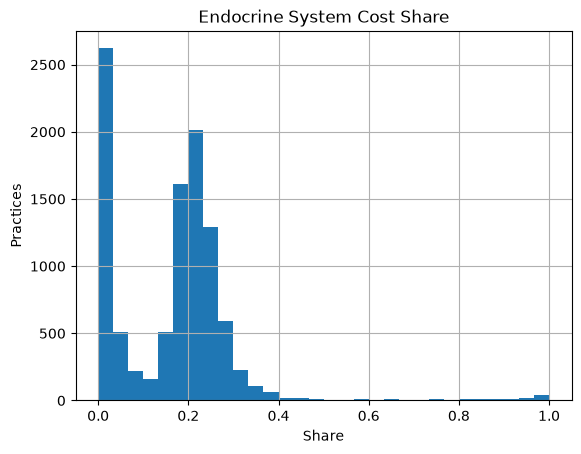

In [ ]:

# Cost histogram for important bnf chapter

import matplotlib.pyplot as plt

pdf["cost_share_06"].hist(bins=30)

plt.title("Endocrine System Cost Share")
plt.xlabel("Share")
plt.ylabel("Practices")

plt.show()

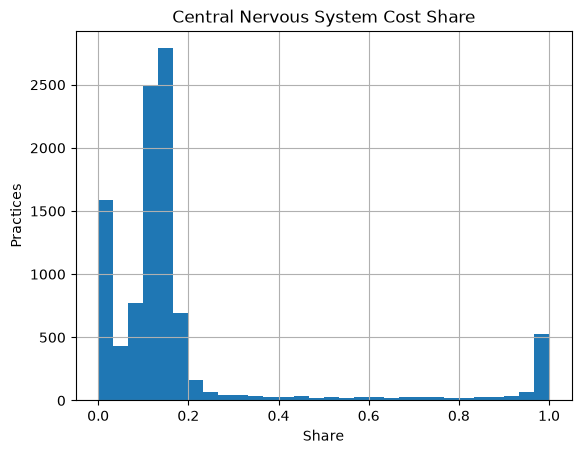

In [ ]:
# Cost histogram for important bnf chapter

pdf["cost_share_04"].hist(bins=30)

plt.title("Central Nervous System Cost Share")
plt.xlabel("Share")
plt.ylabel("Practices")

plt.show()


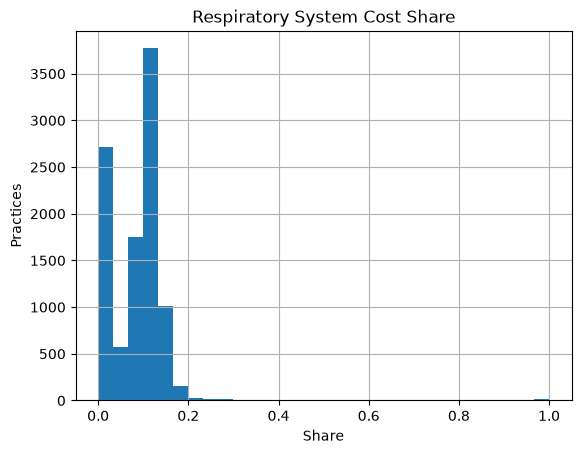

In [ ]:
# Cost histogram for important bnf chapter

pdf["cost_share_03"].hist(bins=30)

plt.title("Respiratory System Cost Share")
plt.xlabel("Share")
plt.ylabel("Practices")

plt.show()


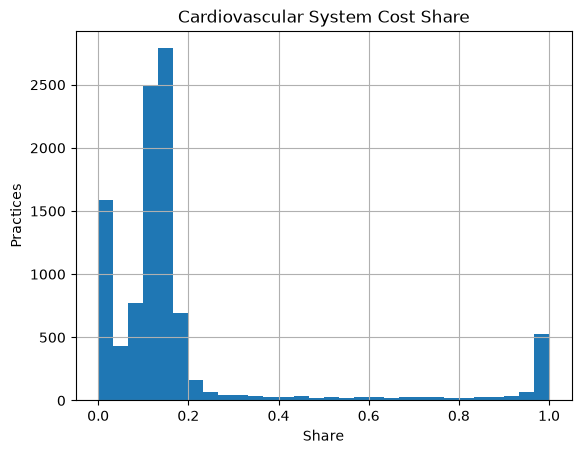

In [ ]:
# Cost histogram for important bnf chapter

pdf["cost_share_04"].hist(bins=30)

plt.title("Cardiovascular System Cost Share")
plt.xlabel("Share")
plt.ylabel("Practices")

plt.show()

In [ ]:
# Generate correlation matrix

corr = pdf.corr(numeric_only=True)

corr

,cost_share_01,cost_share_02,cost_share_03,cost_share_04,cost_share_05,cost_share_06,cost_share_07,cost_share_08,cost_share_09,cost_share_10,...,item_share_12,item_share_13,item_share_14,item_share_15,item_share_18,item_share_19,item_share_20,item_share_21,item_share_22,item_share_23
cost_share_01,1.000000,-0.006799,0.062695,-0.158653,-0.032734,0.015538,-0.031369,-0.010452,0.078852,0.054815,...,-0.016952,-0.070971,0.021607,0.032616,-0.005653,-0.024468,-0.073627,-0.129033,-0.053996,-0.060162
cost_share_02,-0.006799,1.000000,0.067630,-0.208227,-0.191948,0.107873,-0.033480,-0.006747,0.047758,-0.061591,...,-0.105423,-0.164134,0.047860,-0.065222,-0.001695,-0.034369,-0.080370,-0.126531,-0.043836,-0.065241
cost_share_03,0.062695,0.067630,1.000000,-0.239043,-0.171334,0.195316,-0.038450,0.004241,0.127860,-0.046589,...,-0.043263,-0.141043,0.076198,-0.118062,-0.010742,-0.052938,-0.119482,-0.108526,-0.062442,-0.094020
cost_share_04,-0.158653,-0.208227,-0.239043,1.000000,-0.181232,-0.315059,-0.133019,-0.086600,-0.173436,-0.090323,...,-0.127234,-0.183832,-0.077298,0.099527,0.015187,-0.015471,-0.086714,-0.213554,-0.059729,-0.079902
cost_share_05,-0.032734,-0.191948,-0.171334,-0.181232,1.000000,-0.293979,-0.008887,-0.079693,-0.191539,0.025381,...,0.120990,0.134360,-0.096892,0.011425,-0.002191,0.028165,-0.043696,-0.074574,-0.040286,-0.044745
cost_share_06,0.015538,0.107873,0.195316,-0.315059,-0.293979,1.000000,0.010668,0.023032,0.145910,-0.064843,...,-0.130581,-0.192467,0.104800,-0.112688,-0.009502,-0.063979,-0.124913,0.011834,-0.064623,-0.100137
cost_share_07,-0.031369,-0.033480,-0.038450,-0.133019,-0.008887,0.010668,1.000000,-0.001895,-0.044044,-0.002580,...,-0.000708,0.013829,-0.000934,0.000078,0.000591,-0.012125,-0.047316,-0.043349,-0.027701,-0.040476
cost_share_08,-0.010452,-0.006747,0.004241,-0.086600,-0.079693,0.023032,-0.001895,1.000000,-0.013864,0.016133,...,-0.046813,0.058259,0.018785,0.008317,0.025932,-0.008064,-0.032243,-0.049010,-0.019265,-0.030316
cost_share_09,0.078852,0.047758,0.127860,-0.173436,-0.191539,0.145910,-0.044044,-0.013864,1.000000,-0.041126,...,-0.103988,-0.122933,0.049959,-0.054158,-0.007299,-0.037215,-0.077297,-0.104758,-0.044675,-0.057523
cost_share_10,0.054815,-0.061591,-0.046589,-0.090323,0.025381,-0.064843,-0.002580,0.016133,-0.041126,1.000000,...,0.003737,0.036573,-0.024497,-0.022348,-0.001690,-0.008587,-0.036184,-0.059567,-0.024773,-0.034195


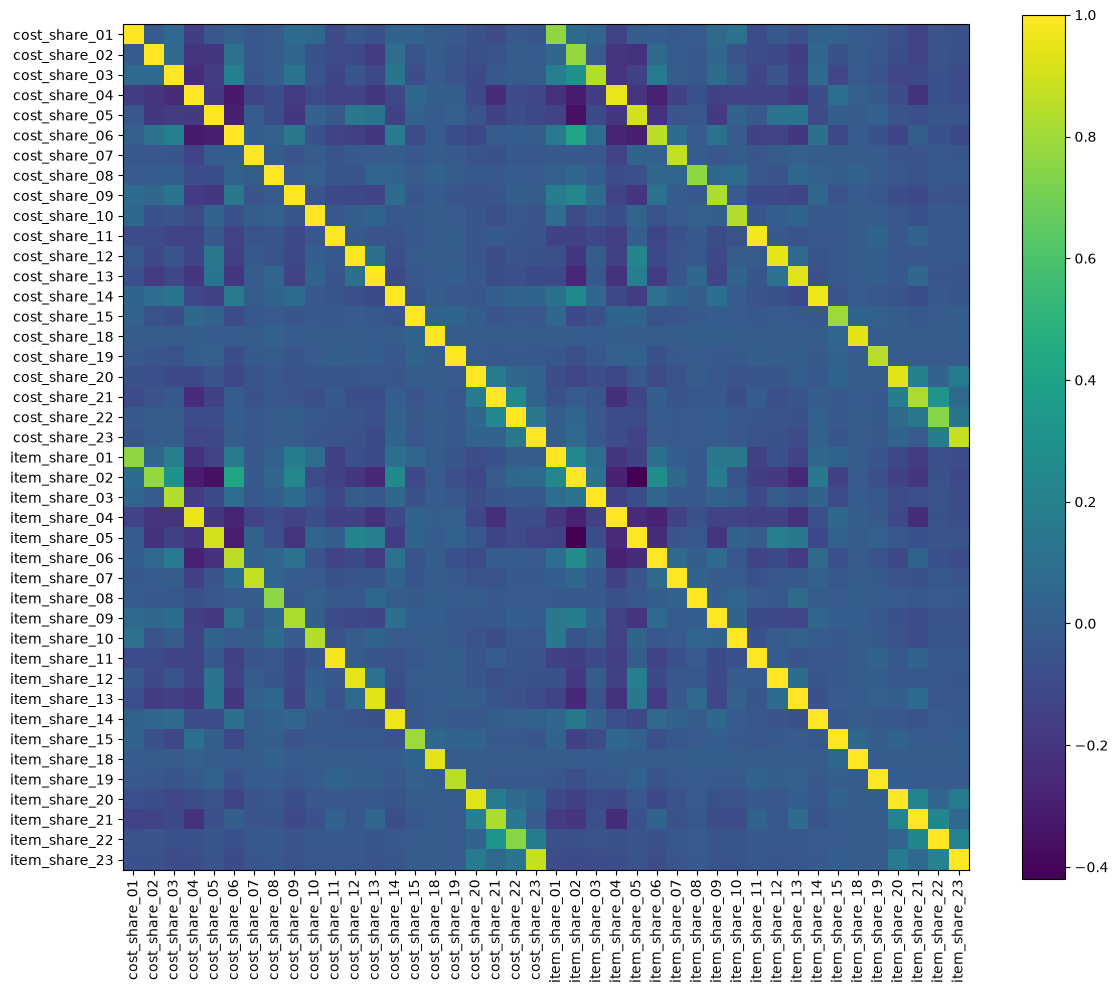

In [ ]:

# Generate heat map using correlation matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.tight_layout()

plt.show()

In [ ]:
# Assemble features for pca

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_features = assembler.transform(df)

In [ ]:
# Run pca

from pyspark.ml.feature import PCA

pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pca"
)

model = pca.fit(df_features)

pca_df = model.transform(df_features)

26/06/29 09:55:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/29 09:55:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/06/29 09:55:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


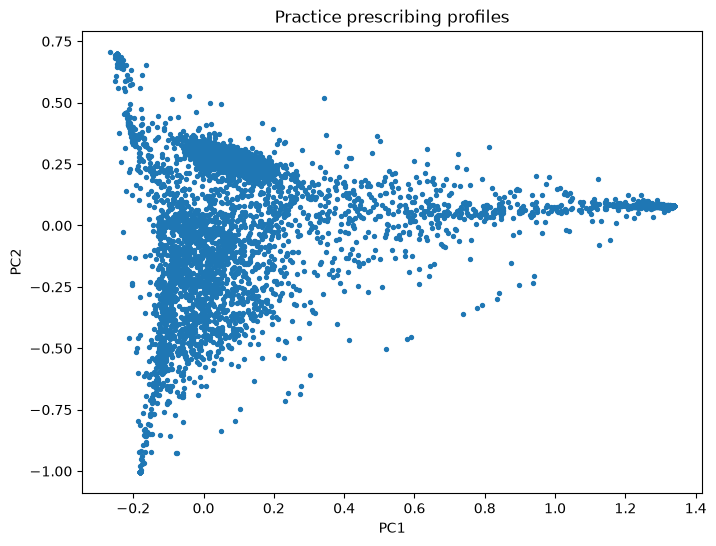

In [ ]:
# Plot pca

pca_pdf = (
    pca_df
    .select("pca")
    .toPandas()
)

pca_pdf["PC1"] = pca_pdf["pca"].apply(lambda x: x[0])
pca_pdf["PC2"] = pca_pdf["pca"].apply(lambda x: x[1])

plt.figure(figsize=(8,6))

plt.scatter(
    pca_pdf["PC1"],
    pca_pdf["PC2"],
    s=8
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Practice prescribing profiles")

plt.show()

In [ ]:
# Elbow method


from pyspark.ml.clustering import KMeans

costs = []

for k in range(2,11):

    model = (
        KMeans(
            k=k,
            seed=42
        )
        .fit(df_features)
    )

    costs.append(model.summary.trainingCost)

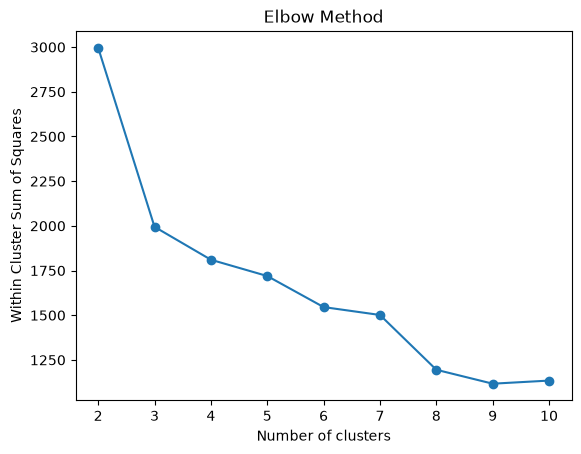

In [ ]:
# Elbow plot

plt.plot(range(2,11), costs, marker="o")

plt.xlabel("Number of clusters")

plt.ylabel("Within Cluster Sum of Squares")

plt.title("Elbow Method")

plt.show()

In [ ]:
# Silhouette Scores


from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator()

scores = []

for k in range(2,11):

    model = (
        KMeans(
            k=k,
            seed=42
        )
        .fit(df_features)
    )

    predictions = model.transform(df_features)

    score = evaluator.evaluate(predictions)

    scores.append(score)

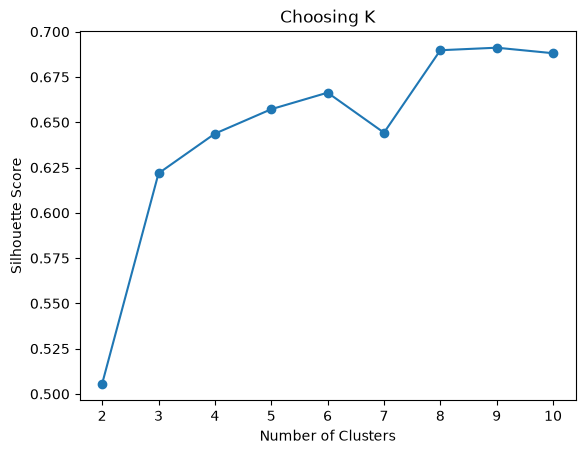

In [45]:
# Plot Silhouette Scores


plt.plot(range(2,11), scores, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Choosing K")

plt.show()